In [40]:
from optimizer_functions import *
from heuristic_optimizer import solve_large_instance
import pandas as pd
import pprint

In [41]:
# ── 1. load datasets ────────────────────────────────────────────────

# Load the trips data
df_raw = pd.read_csv('transit_departure_updated_energy.csv')
#df_raw = df_raw[df_raw['Line ID'] != '1-1'] 
print(f"Trips before cleaning: {df_raw.shape[0]}")

df = process_transit_data(df_raw, tolerance=1, timestep_min=15)
print(f"Trips after cleaning: {df.shape[0]}")

#target_lines = ['1-11', '1-13', '1-136', '1-14A', '1-14G', '1-15', '1-15A', '1-15B', '1-18', '1-214', '1-22', '1-236', '1-25', '1-272', '1-277', '1-279', '1-28', '1-280', '1-281', '1-282', '1-284', '1-289', '1-29', '1-290', '1-294', '1-31', '1-332', '1-36', '1-382', '1-384', '1-391', '1-4', '1-52', '1-54', '1-56', '1-57', '1-577', '1-58', '1-584', '1-59', '1-70', '1-74', '1-79B', '1-80', '1-800', '1-801', '1-802', '1-803', '1-804', '1-807', '1-82', '1-82A', '1-84', '1-86G', '1-88', '1-9', '1-94']
target_lines = ['1-11', '1-15', '1-4', '1-80']  # Reduced set for quicker testing
df = df[df["Line ID"].isin(target_lines)].copy()
energy_price_data = pd.read_excel('tou_tariffs.xlsx', sheet_name=None)
energy_price = energy_price_data['Sheet1']['Price'].to_list()
energy_price = resample_time_series(energy_price, original_delta=1, target_delta=1/4, method='average')

df.to_excel('optimization_dataset.xlsx', index=False)
print(f"Filtered trips: {df.shape[0]}")

Trips before cleaning: 3737
Trips after cleaning: 3629
Filtered trips: 236


In [42]:
# ── 3. Bus system compositon ────────────────────────────────────────────────
# Example 1 - Slow chargers, large batteries
bus_counts     = [21] 
battery_sizes  = [300]
charger_counts = [5]
charger_powers = [80]

# Example 2 - Fast chargers, smaller batteries
#bus_counts     = [24] 
#battery_sizes  = [150]
#charger_counts = [5]
#charger_powers = [400]

C_bat, alpha = build_fleet_and_chargers(
    bus_counts, battery_sizes,
    charger_counts, charger_powers
)

In [43]:
# ── 4. extract data sets ───────────────────────────────────────────────
# Extract the necessary data from the DataFrame
start = df['Departure Step'].astype(int).to_list()
end   = df['Arrival Step'].astype(int).to_list()
gama =df['Energy per timestep'].astype(float).to_list()

In [44]:
#solution, objective_value = solve_large_instance(
#    start, end, alpha, gama, C_bat, energy_price,
#    max_iterations=200  # number of local search iterations
#)

In [45]:
# ── 5. Build your model as before ────────────────────────────────────────────
model = optimization(start, end, alpha, gama, C_bat, energy_price,
                     E_0=0.2, E_min=0.2, E_max=1.00, E_end=0.2, delta_t=1/4, relaxed_binary=False)


Number of trips: 236, Time steps: 96, Buses: 21, Chargers: 5
Parameters initialized
Variables initialized
Objective function defined
Constraints defined


In [46]:
# ── 6. Configure and solve with warm‐start ──────────────────────────────────          
# ── 6.1. Configure Gurobi options for heuristics & warm‐start ────────────────
solver = SolverFactory('gurobi')
solver.options.update({
    'TimeLimit'      : 60,      # stop after 6 min
    'MIPGap'         : 0.01,     # 1% optimality gap
    'Heuristics'     : 1.0,      # maximum time to primal heuristics
    'MIPFocus'       : 1,        # focus on finding good feasible solutions
    'Presolve'       : 2,        # aggressive presolve
    'Cuts'           : 3,        # more cutting‐plane generation
    'NodefileStart'  : 0.5,      # start nodefile earlier (in GB)
    'PoolSearchMode' : 2,        # find more solutions
    'ImproveStartTime': 0,       # start improving incumbent immediately
    # 'BarConvTol'   : 1e-4,     # (if using barrier)
})
# ── 6.2. Solve with warmstart turned on ──────────────────────────────────────
results = solver.solve(model,
                       tee=True,
                       warmstart=True)   # tells Pyomo to pass the MIP start to Gurobi

# Print only the optimal objective value
print("Optimal objective value:", pyo.value(model.obj))

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-18
Read LP format model from file /var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/tmpm6nuei0k.pyomo.lp
Reading time = 1.55 seconds
x1: 45639 rows, 487968 columns, 1499391 nonzeros
Read MIP start from file /var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/tmpid6_ouj7.gurobi.mst
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter Heuristics to value 1
Set parameter MIPFocus to value 1
Set parameter Presolve to value 2
Set parameter Cuts to value 3
Set parameter NodefileStart to value 0.5
Set parameter PoolSearchMode to value 2
Set parameter ImproveStartTime to value 0
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[rosetta2] - Darwin 24.6.0 24G90)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 45639 rows, 487968 columns and 1499391 nonzeros
Model fingerprint: 0x1dd43bd9
Variable types:

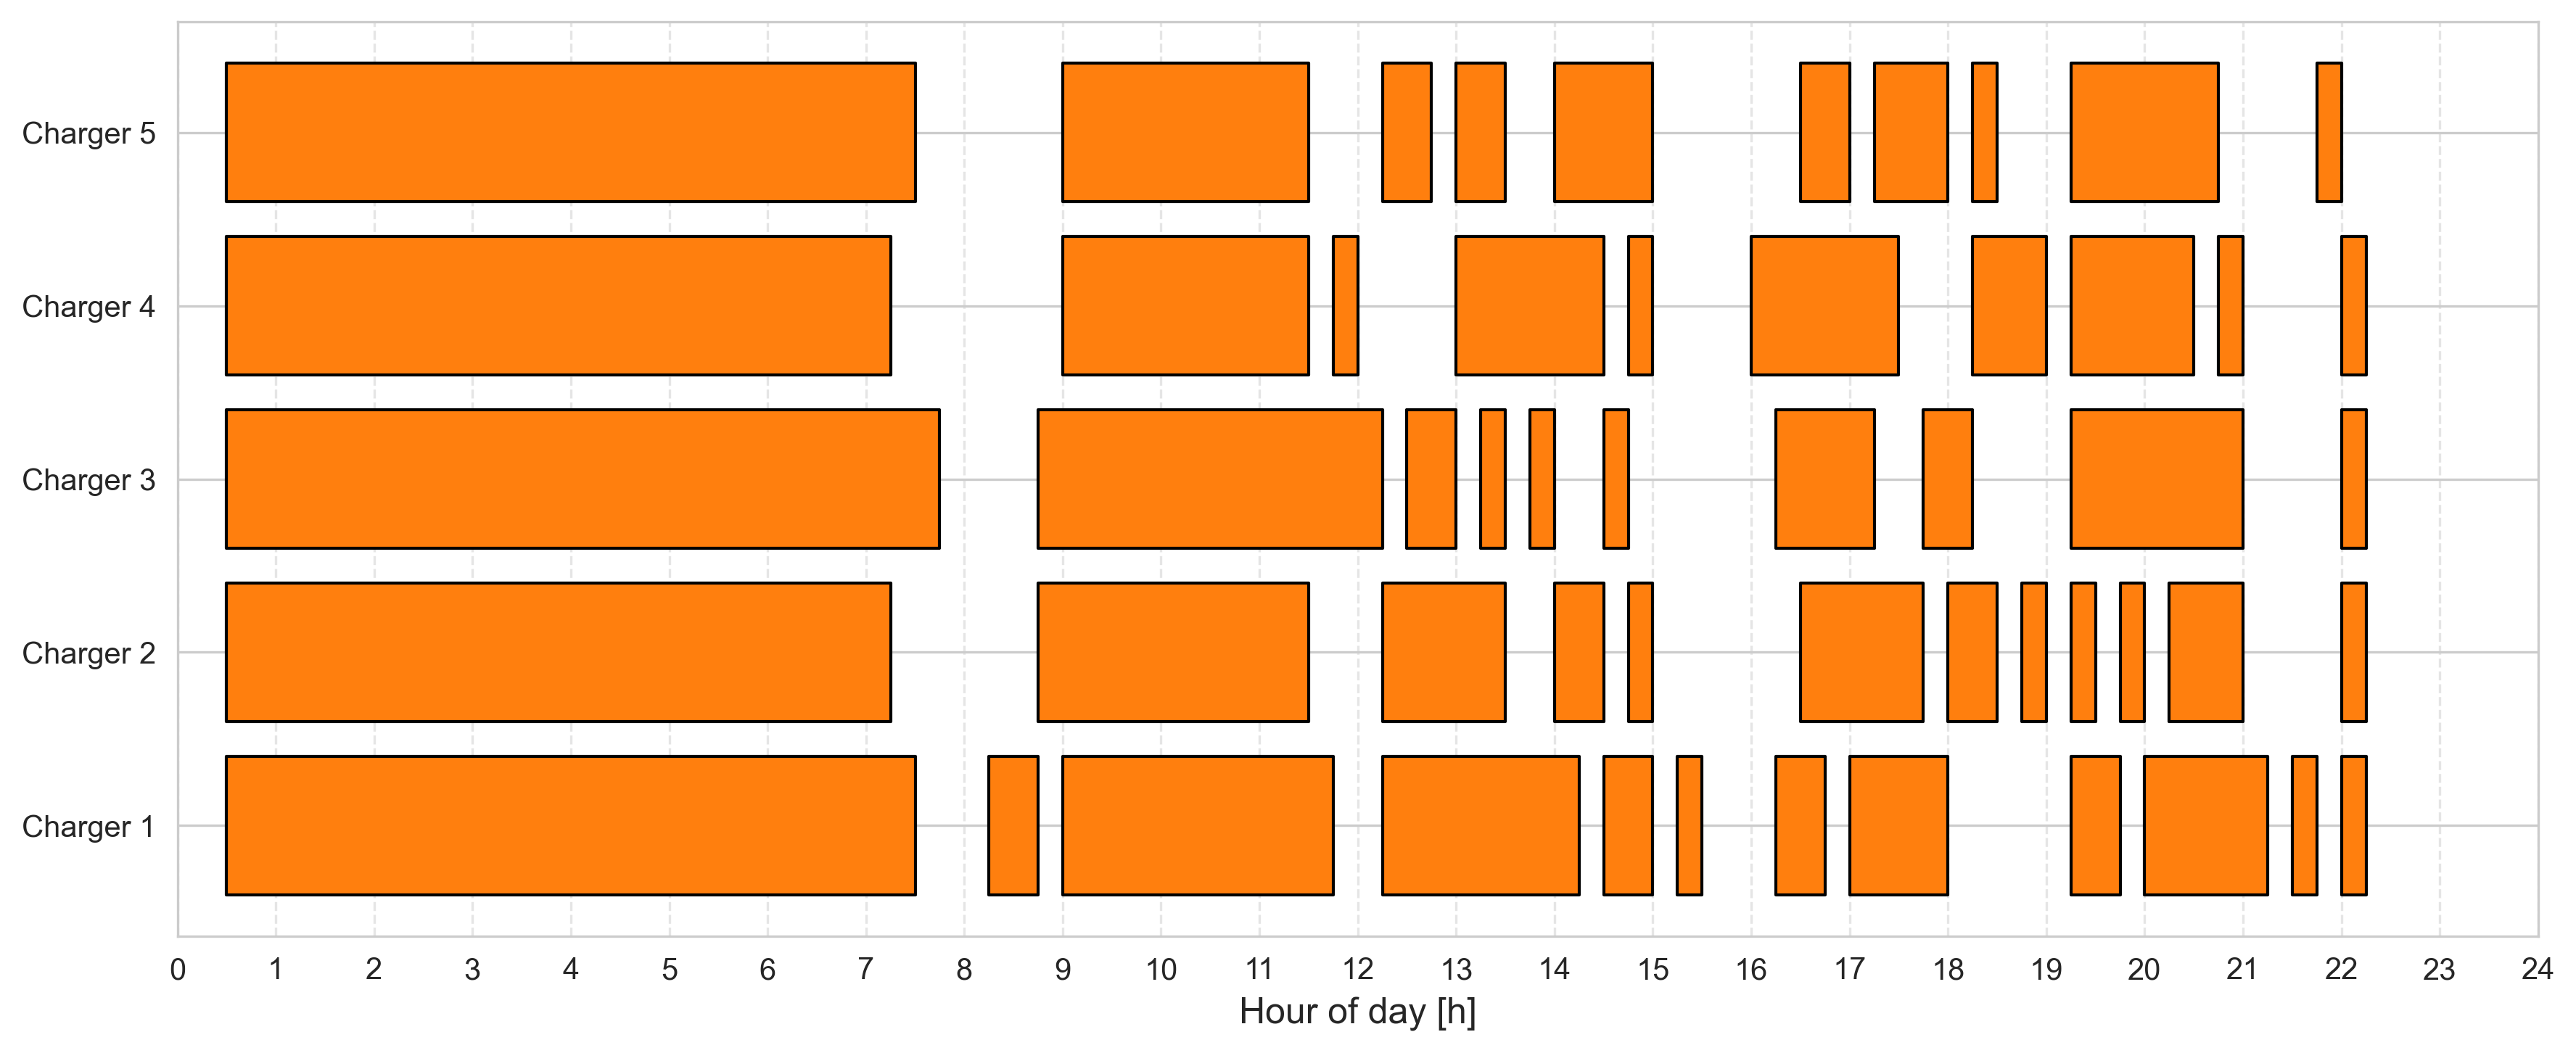

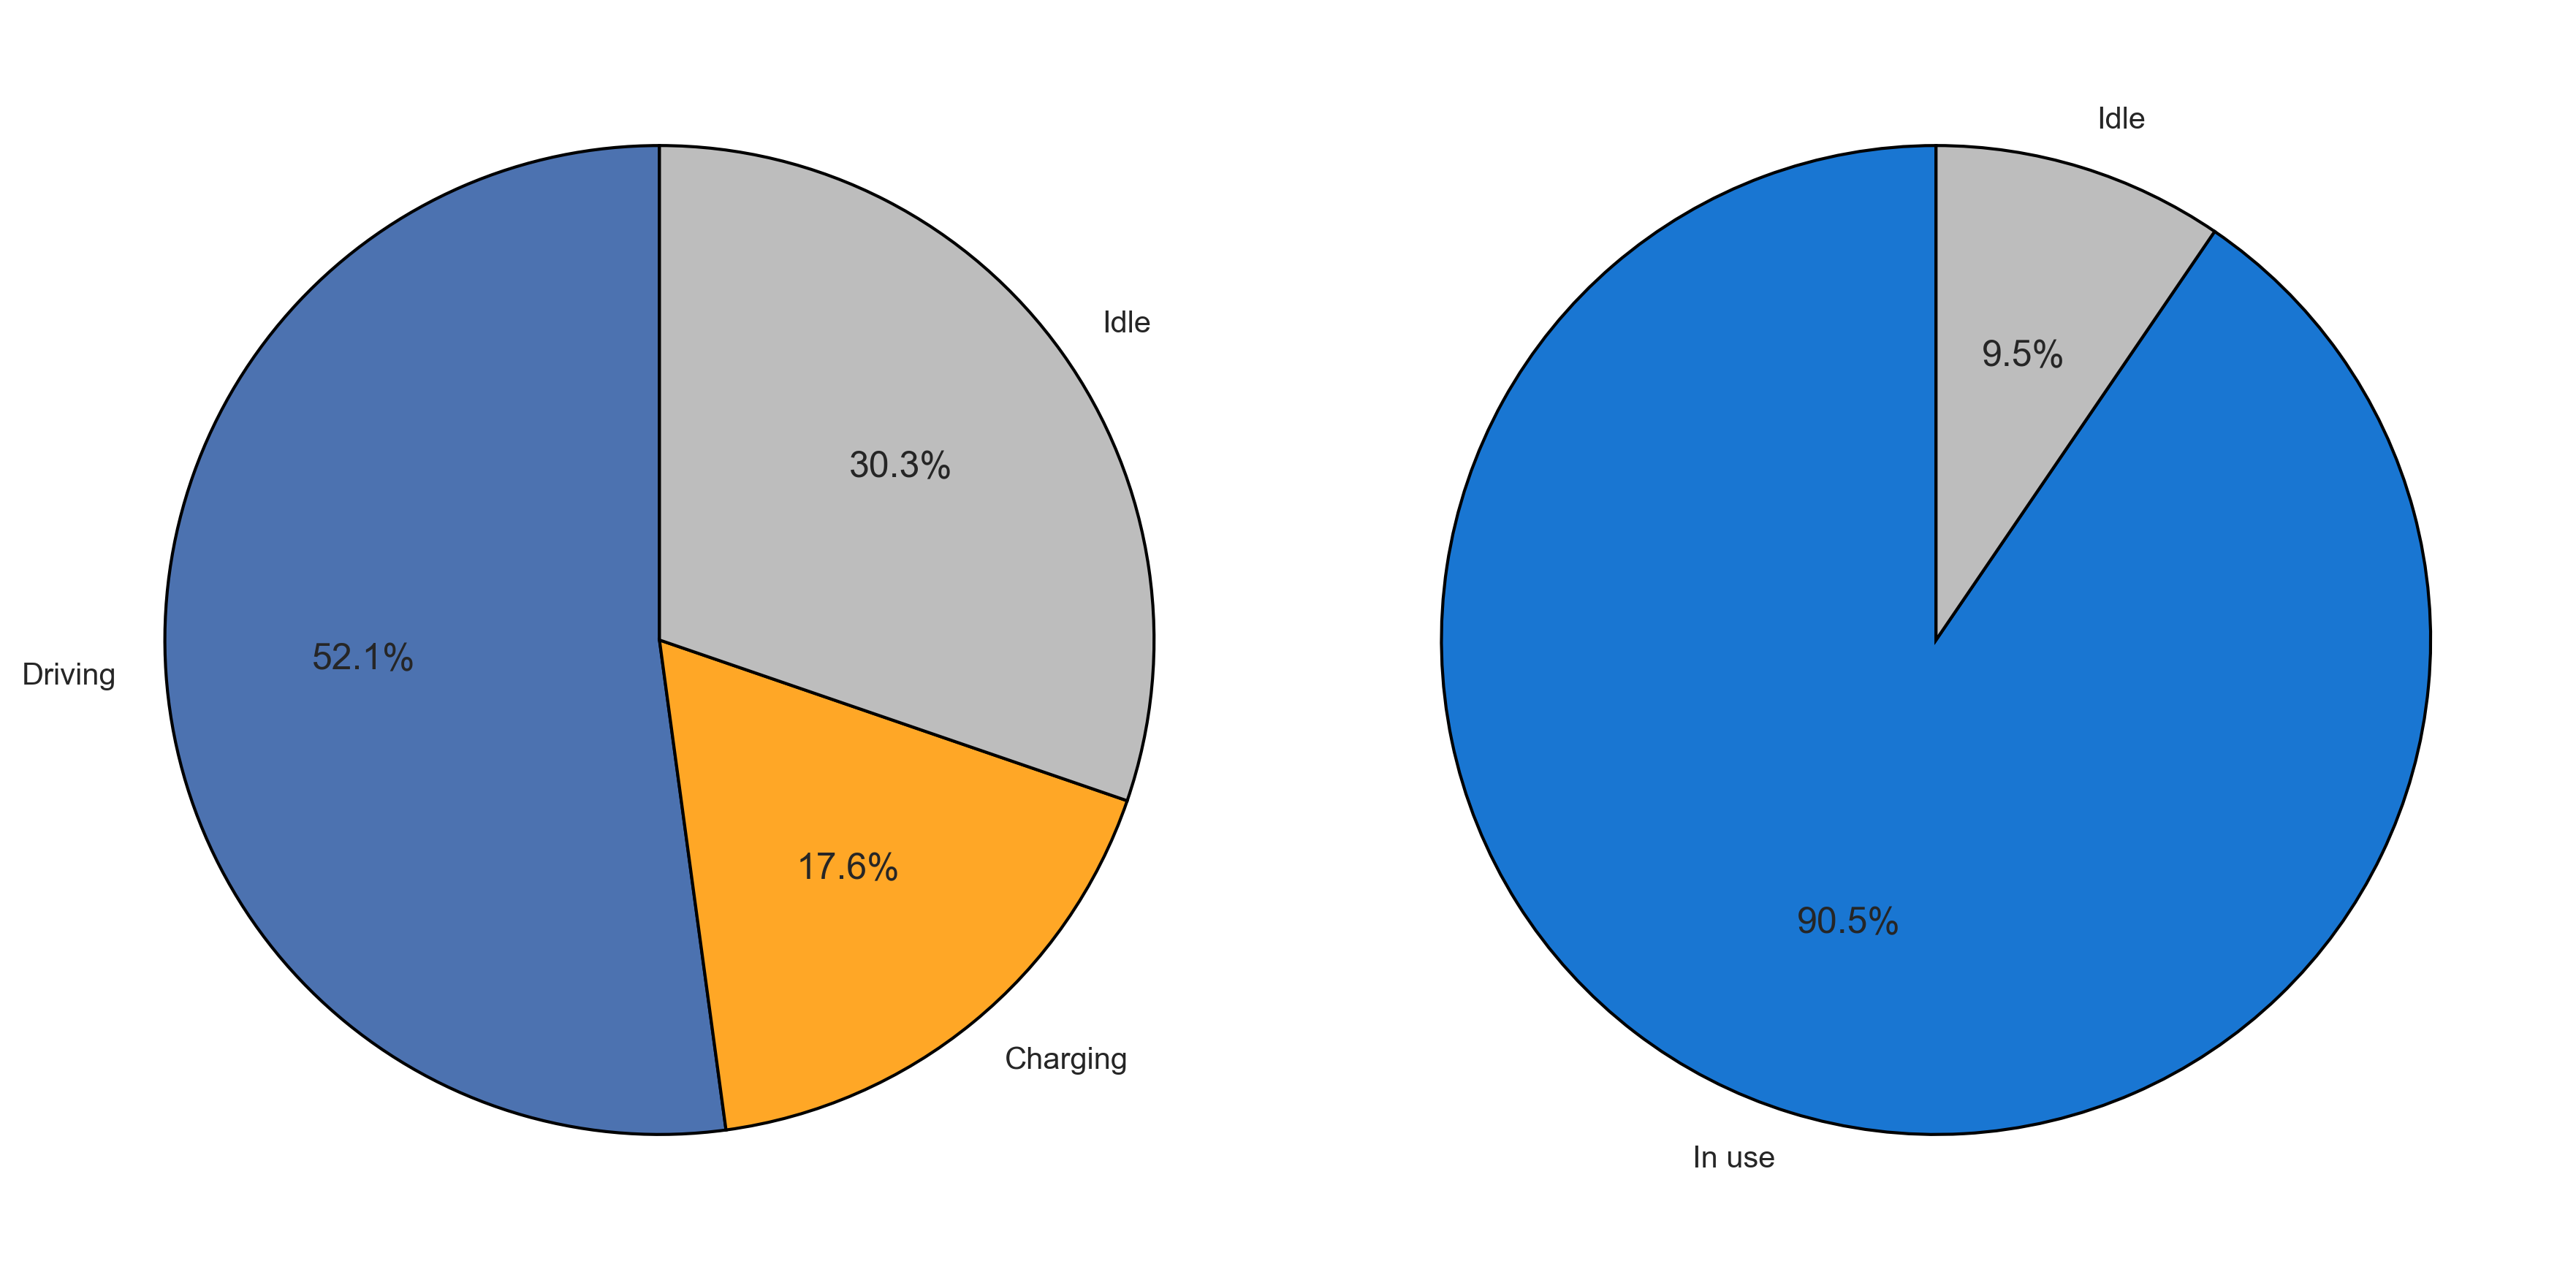

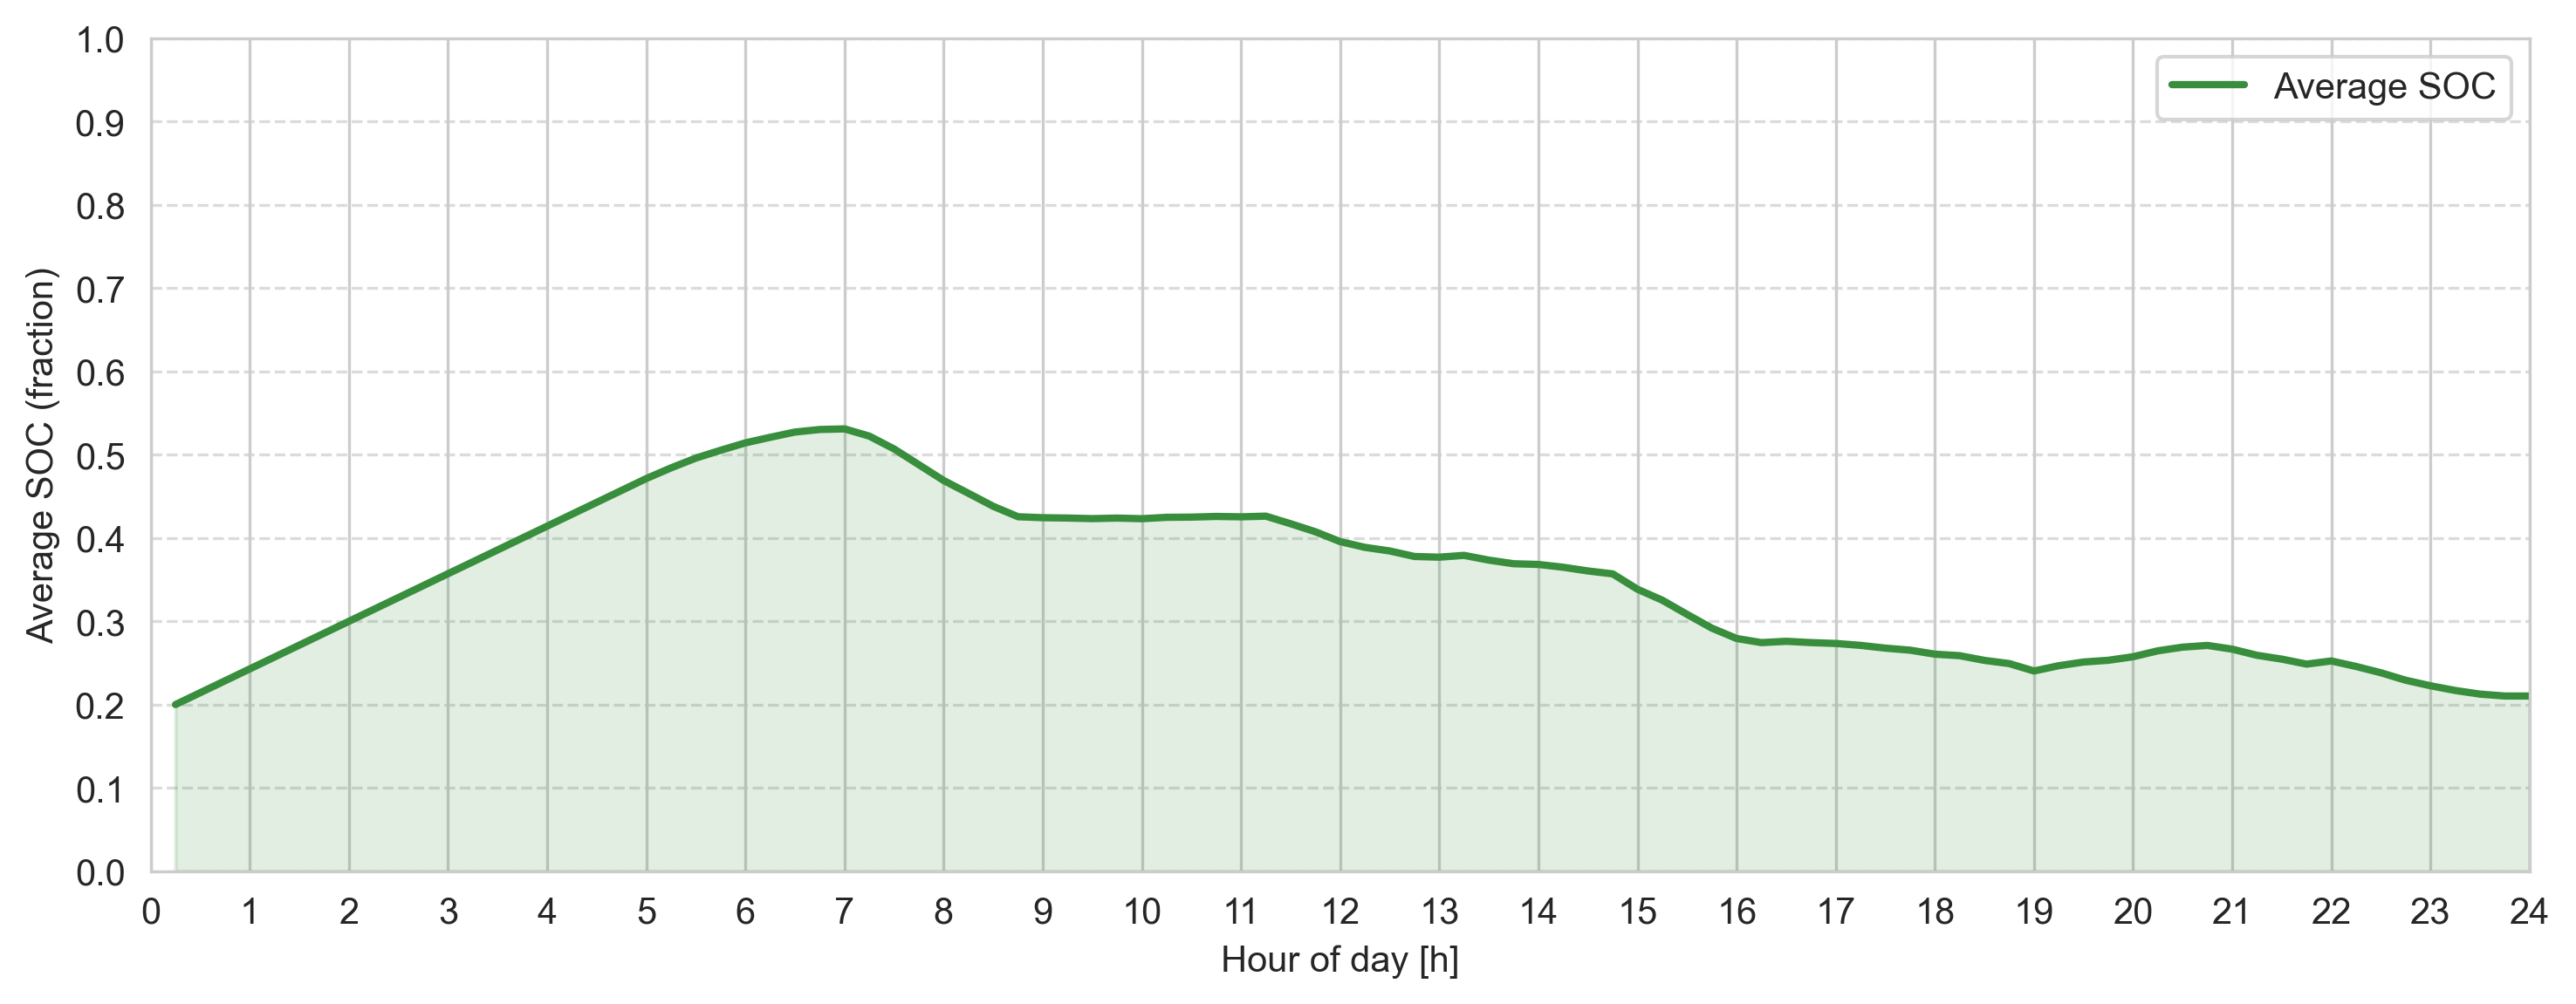

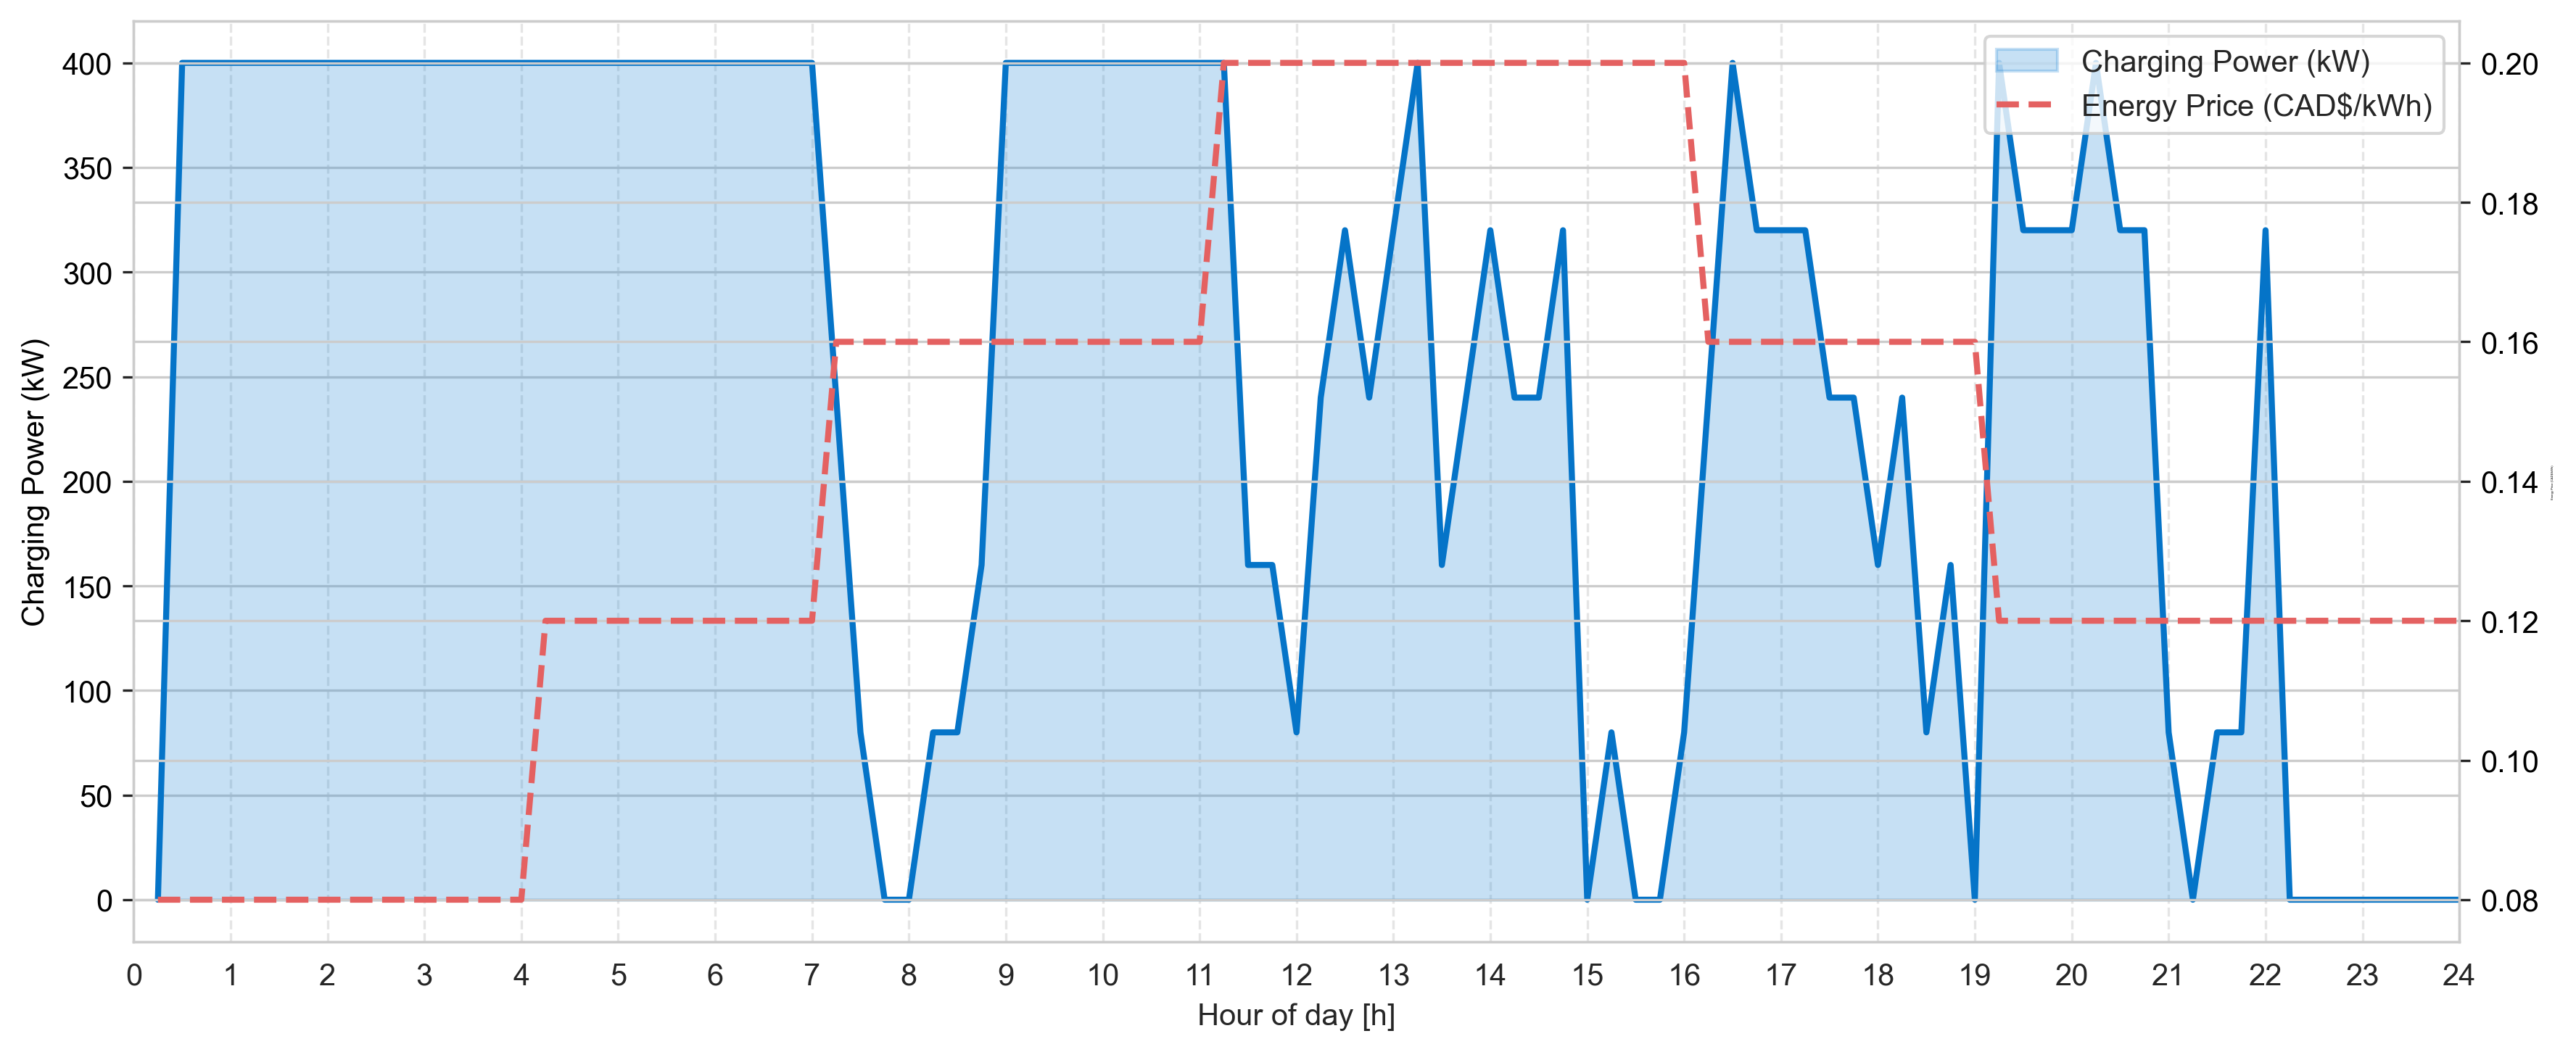

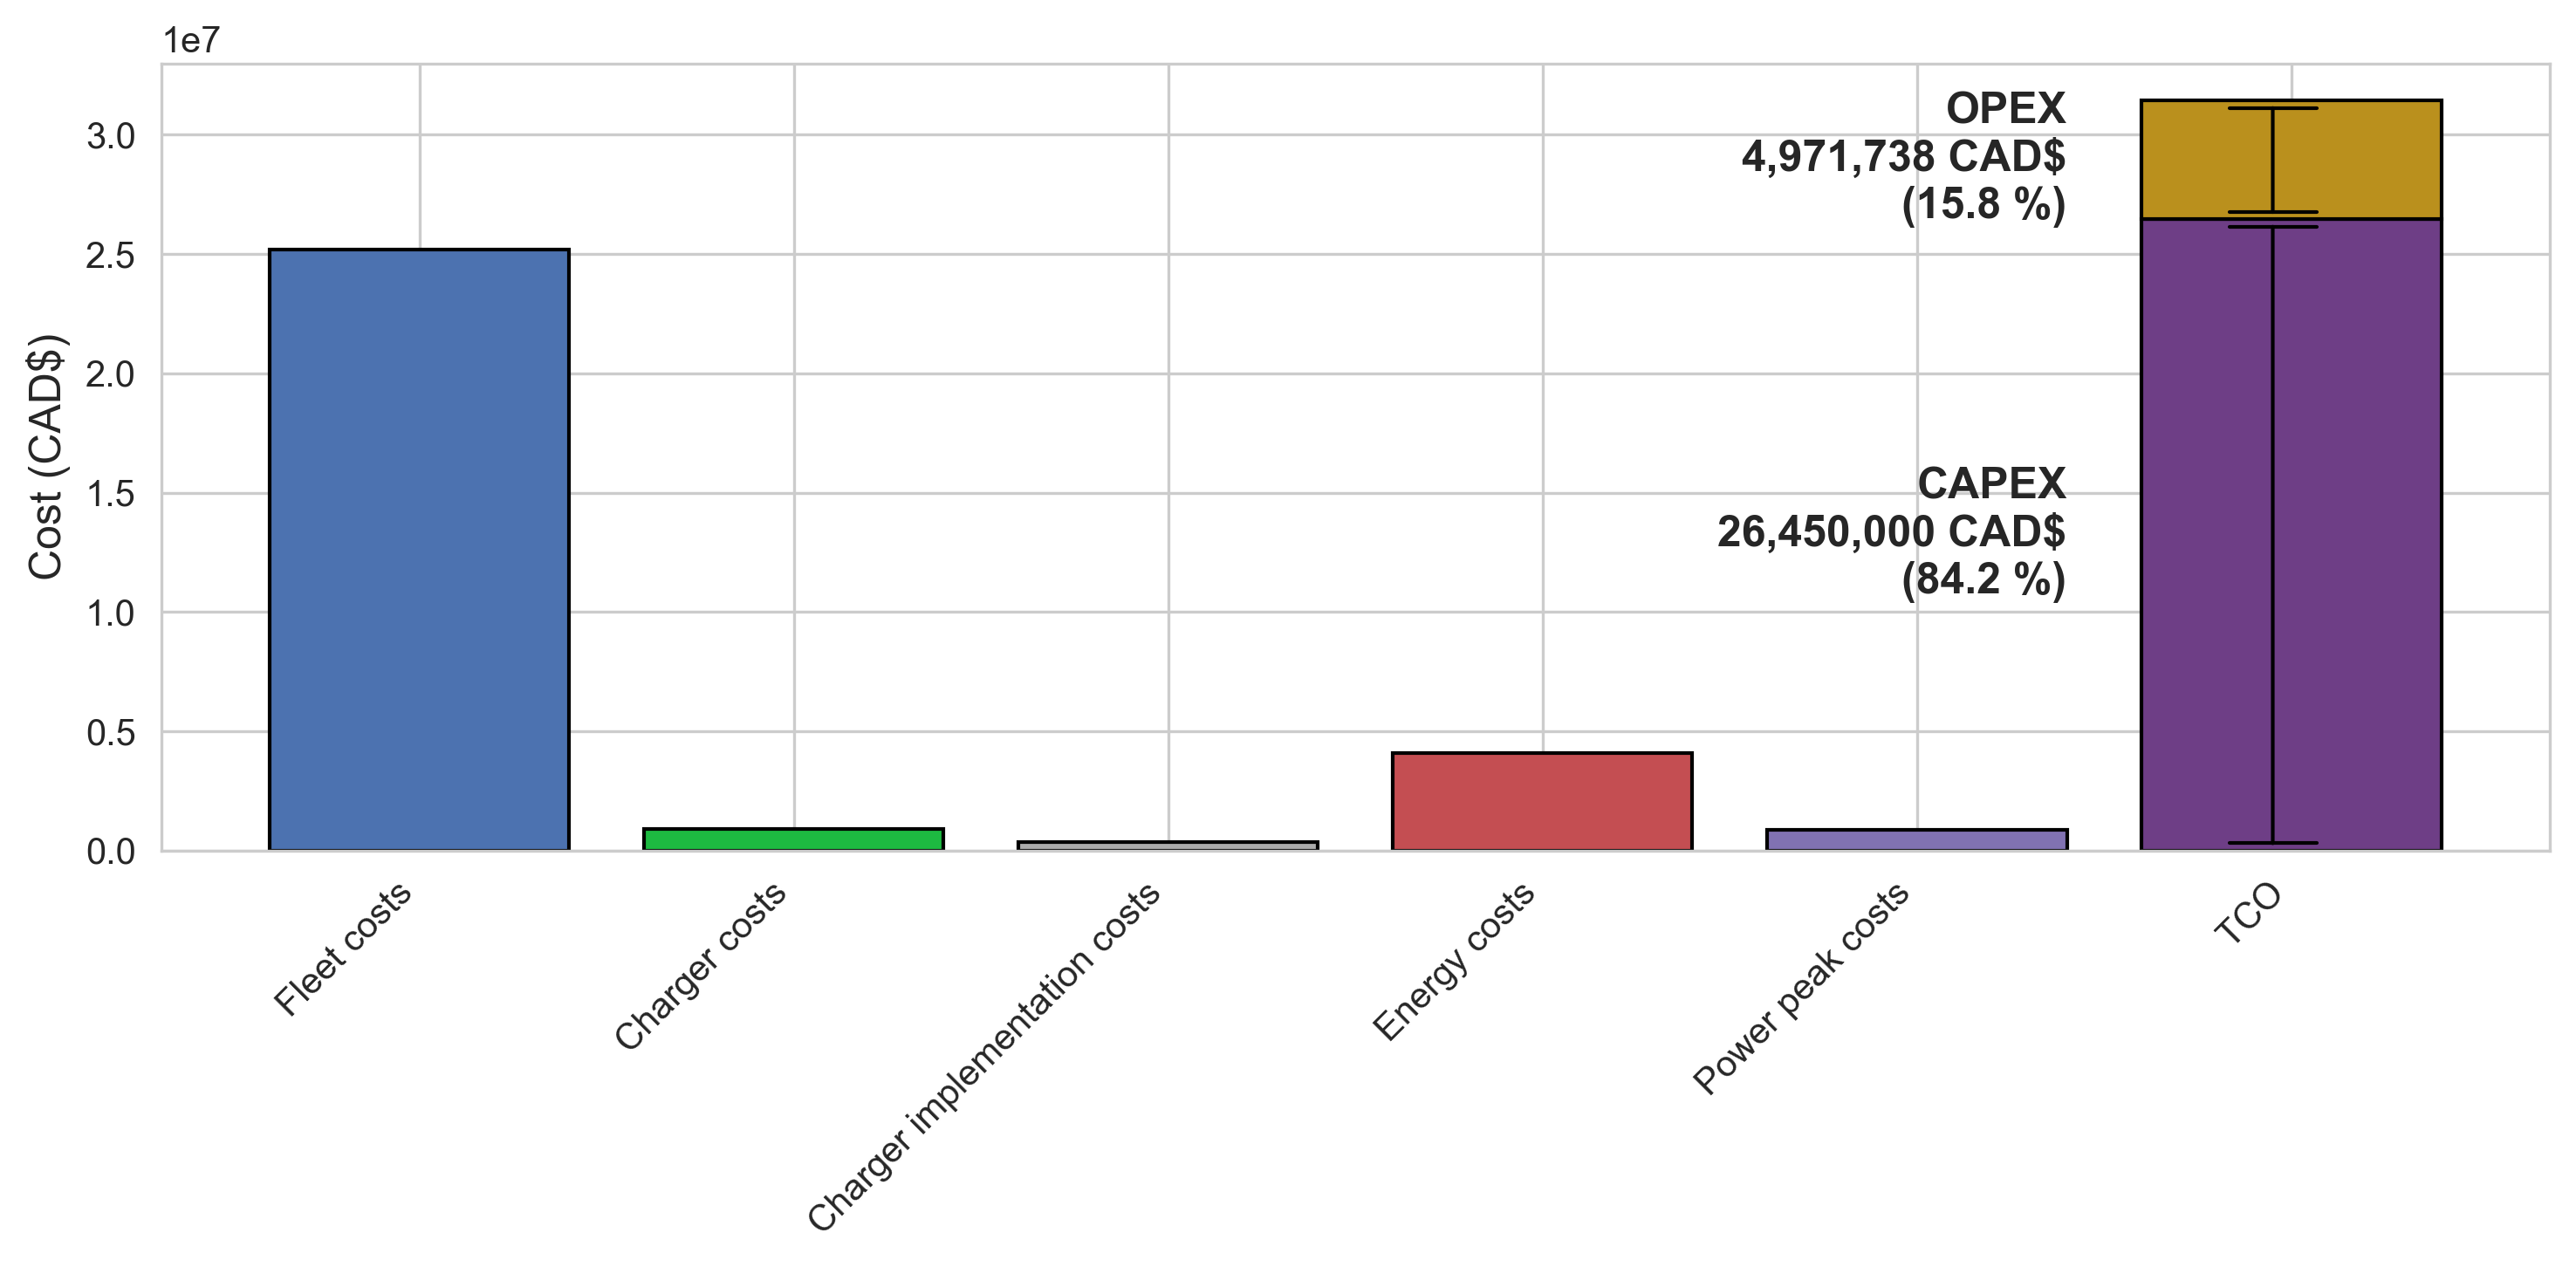

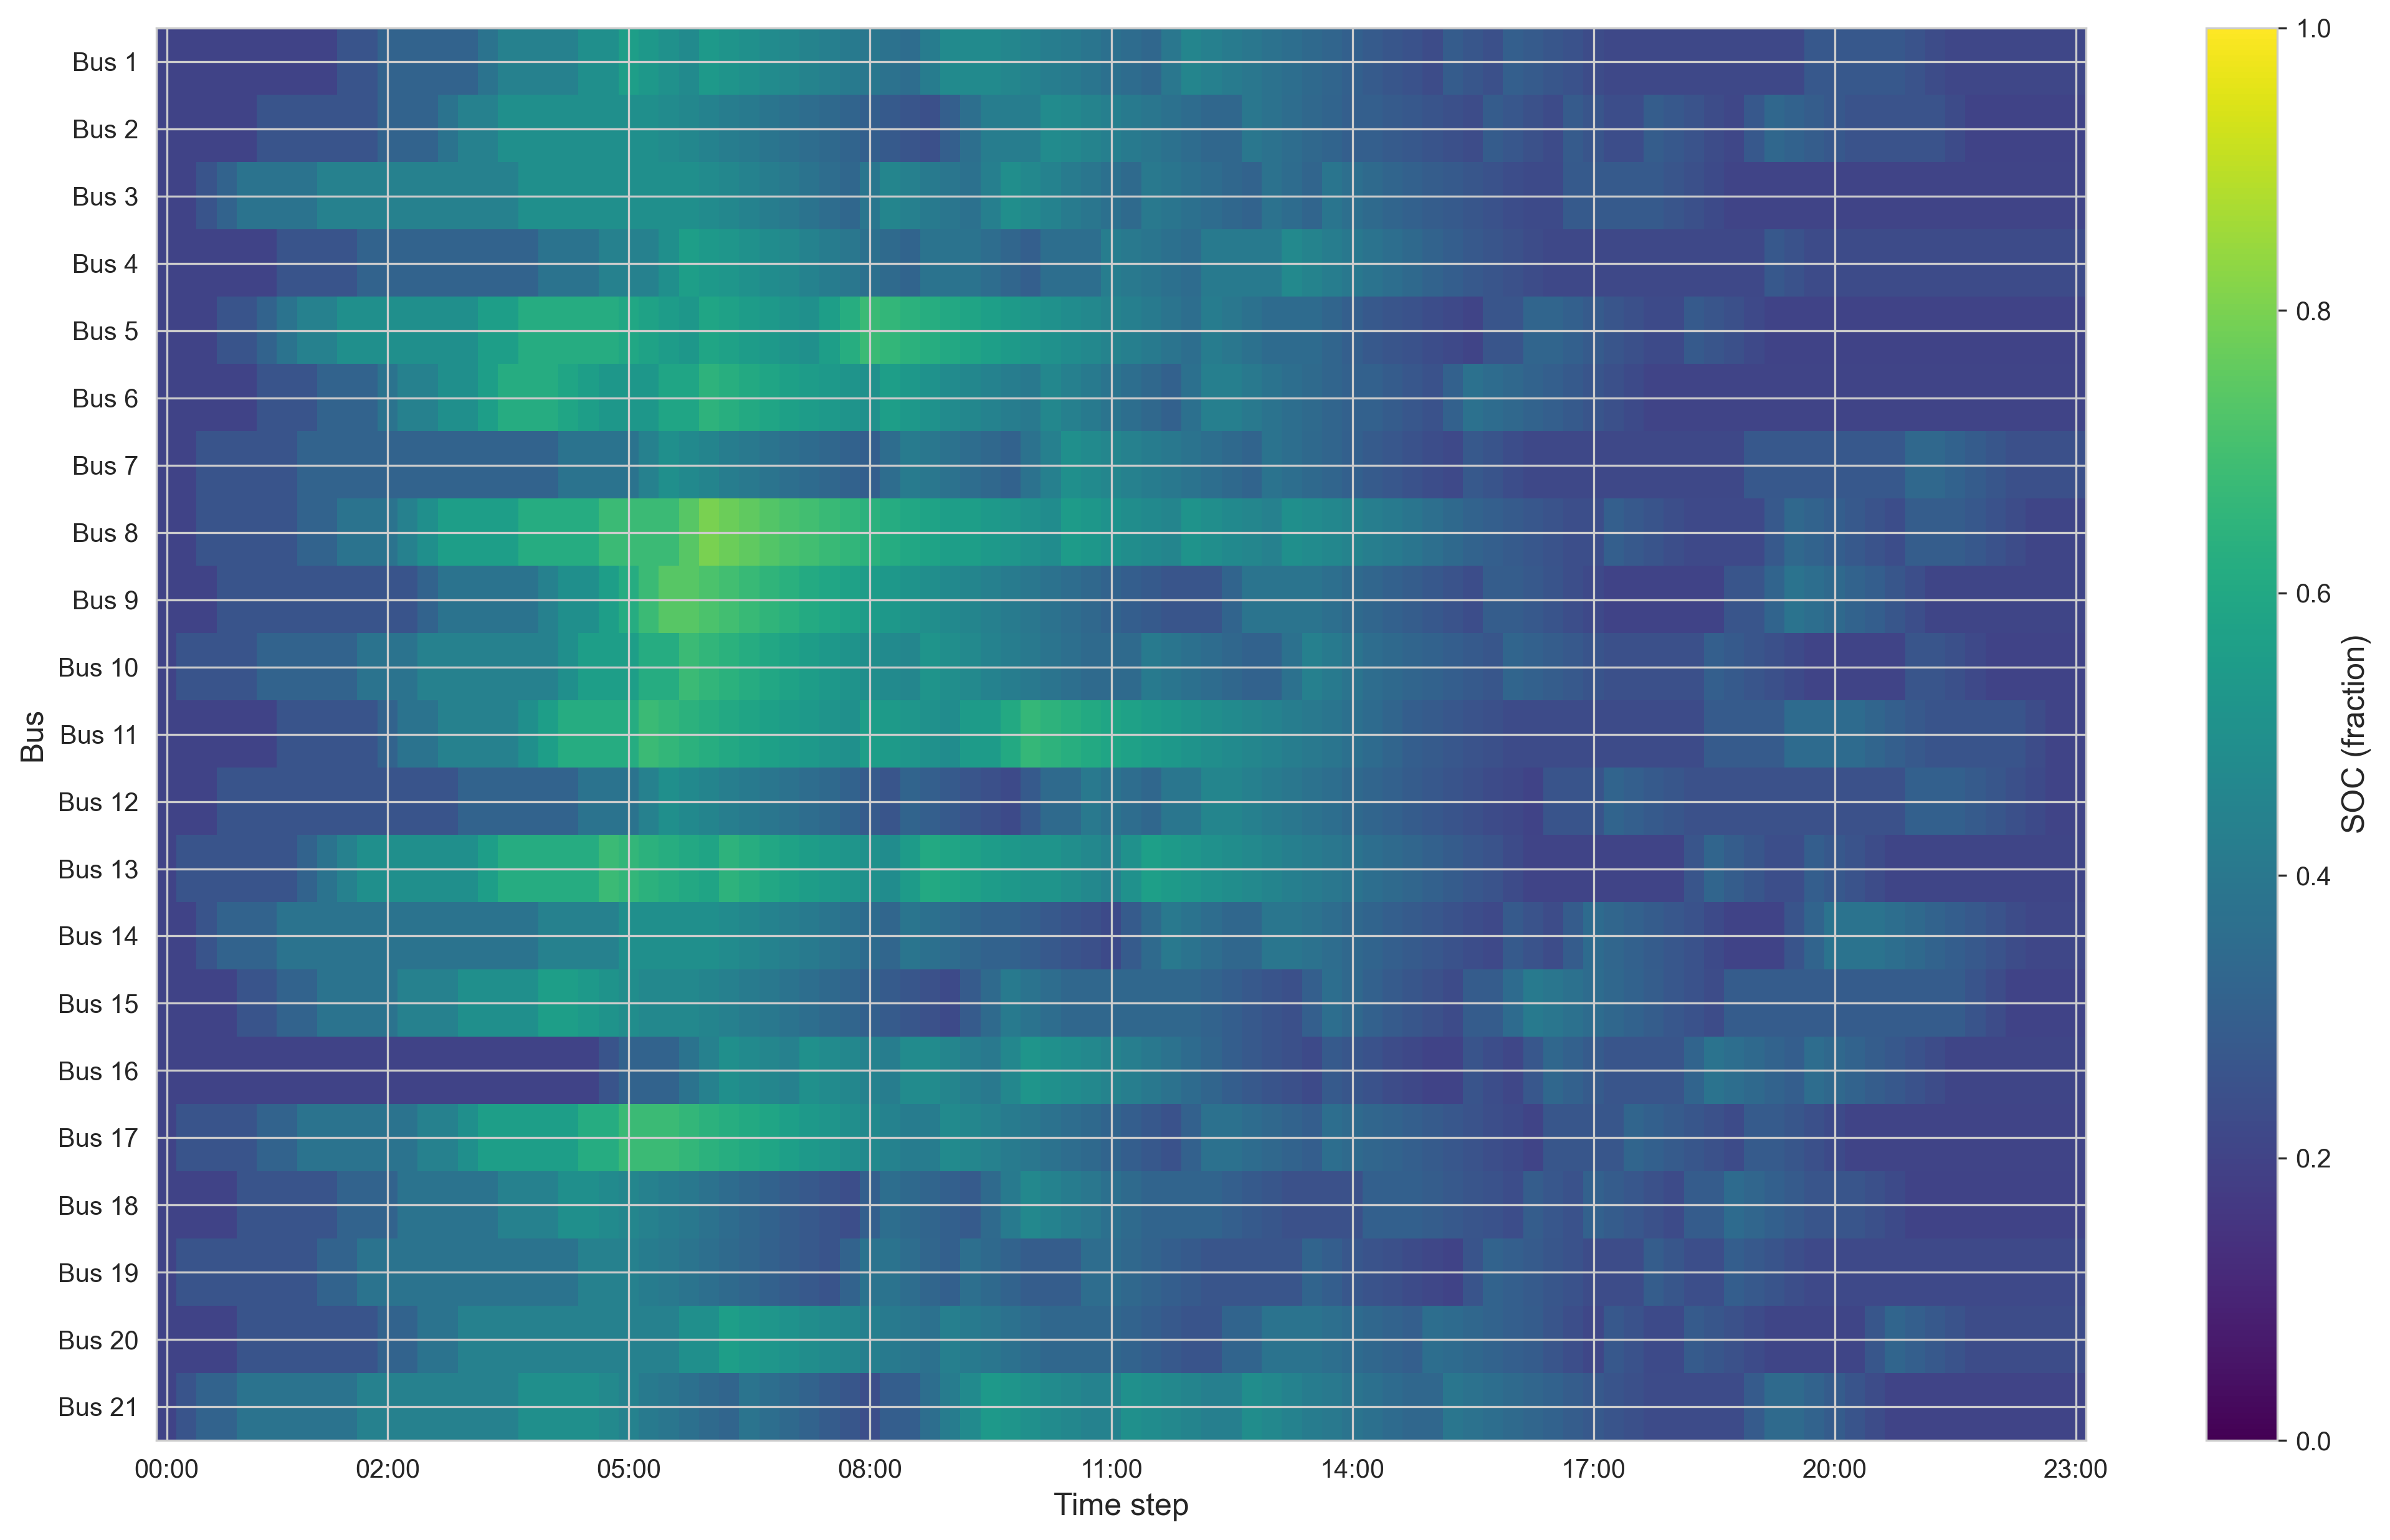

In [47]:
'''
#fast-charging example
plot_optimization_results(
    model,
    vehicle_cost=820000,    # € per bus
    charger_cost=350000,     # € per charger
    implementation_cost=300000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=15
)
'''
#slow-charging example
plot_optimization_results(
    model,
    vehicle_cost=1200000,    # € per bus
    charger_cost=180000,     # € per charger
    implementation_cost=70000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=15
)


In [48]:
'''
export_optimization_summary(
    model,
    vehicle_cost=820000,    # € per bus
    charger_cost=350000,     # € per charger
    implementation_cost=300000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=10,
    filename='optimization_summary_fast_charging.xlsx'
)

'''
export_optimization_summary(
    model,
    vehicle_cost=1200000,    # € per bus
    charger_cost=180000,     # € per charger
    implementation_cost=70000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=10,
    filename='optimization_summary_slow_charging.xlsx'
)


Summary exported to optimization_summary_slow_charging.xlsx
